In [2]:
import pandas as pd
import cv2
import numpy as np
from scipy.signal import savgol_filter
import math
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [3]:
video_path = '/home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4'  # Шлях до твого відео
points = []

def click_event(event, x, y, flags, param):
    global points
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append([x, y])
        print(f"Точка {len(points)}: [{x}, {y}]")

        cv2.circle(frame, (x, y), 5, (0, 0, 255), -1)

        if len(points) > 1:
            cv2.line(frame, tuple(points[-2]), tuple(points[-1]), (0, 255, 0), 2)

        if len(points) == 4:
            cv2.line(frame, tuple(points[3]), tuple(points[0]), (0, 255, 0), 2)
            print(f"pts_video = np.array({points}, dtype=np.float32)")

        cv2.imshow("Calibrator", frame)

cap = cv2.VideoCapture(video_path)


while True:
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Помилка: Не вдалося прочитати відео!")
        exit()


    cv2.namedWindow("Calibrator", cv2.WINDOW_NORMAL)
    # cv2.imshow("Calibrator", frame)
    cv2.setMouseCallback("Calibrator", click_event)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/var-roman/miniconda3/envs/Volleyball_diploma/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/var-roman/miniconda3/envs/Volleyball_diploma/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/var-roman/miniconda3/envs/Volleyball_diploma/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/var-roman/miniconda3/envs/Volleyball_diploma/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io

Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
П

error: OpenCV(4.13.0) /io/opencv/modules/highgui/src/window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'imshow'


Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
Помилка: Не вдалося прочитати відео!
П

In [25]:
def process_ball_trajectory(detections, fps):
    df = pd.DataFrame(detections)

    if df.empty:
        print("Немає детекцій для аналізу.")
        return

    # Відновлюємо пропущені кадри
    min_frame, max_frame = df['frame'].min(), df['frame'].max()
    df.set_index('frame', inplace=True)
    df = df.reindex(range(int(min_frame), int(max_frame) + 1))

    # Інтерполяція та Згладжування
    df['x_interp'] = df['x_meters'].interpolate(method='linear')
    df['y_interp'] = df['y_meters'].interpolate(method='linear')

    window = min(11, len(df))
    if window % 2 == 0: window -= 1

    if window >= 3:
        df['x_smooth'] = savgol_filter(df['x_interp'], window_length=window, polyorder=2)
        df['y_smooth'] = savgol_filter(df['y_interp'], window_length=window, polyorder=2)
    else:
        df['x_smooth'] = df['x_interp']
        df['y_smooth'] = df['y_interp']


    df['dx_meters'] = df['x_smooth'].diff()
    df['dy_meters'] = df['y_smooth'].diff()
    df['distance_step_m'] = np.sqrt(df['dx_meters']**2 + df['dy_meters']**2)

    total_distance_m = df['distance_step_m'].sum()

    dt = 1.0 / fps

    df['speed_ms'] = df['distance_step_m'] / dt
    df['speed_kmh'] = df['speed_ms'] * 3.6

    # Фільтрація аномалій
    max_realistic_speed = 150.0
    df.loc[df['speed_kmh'] > max_realistic_speed, 'speed_kmh'] = np.nan

    valid_speeds = df['speed_kmh'].dropna()
    avg_speed_kmh = valid_speeds.mean()
    max_speed_kmh = valid_speeds.max()

    print(f"Загальна відстань: {total_distance_m:.2f} метрів")
    print(f"Середня швидкість: {avg_speed_kmh:.2f} км/год")
    print(f"Максимальна швидкість: {max_speed_kmh:.2f} км/год")

    # Візуалізація швидкості замість просто координат
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['speed_kmh'], 'b-', linewidth=2, label='Швидкість м\'яча (км/год)')
    plt.title("Графік швидкості м'яча")
    plt.xlabel("Номер кадру")
    plt.ylabel("Швидкість (км/год)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

def pixel_to_meters(pixel_x, pixel_y, matrix):
    point_px = np.array([[[pixel_x, pixel_y]]], dtype=np.float32)
    point_meters = cv2.perspectiveTransform(point_px, matrix)

    real_x = point_meters[0][0][0]
    real_y = point_meters[0][0][1]

    return real_x, real_y

In [2]:
# To load model
# main_model = YOLO('/home/var-roman/Desktop/my_projects/diploma_project/parsing_datasets_scripts/models/ball_best_detec_server_v2.pt')
main_model = YOLO('/training_models/runs/detect/train-4/weights/best.pt')
# main_model = YOLO('/home/var-roman/Desktop/my_projects/diploma_project/parsing_datasets_scripts/models/ball_best_detec_server_v1.pt')

/home/var-roman/anaconda3/envs/Volleyball_diploma/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pts_video = np.array([[405, 606], [1504, 606], [1835, 1027], [73, 1031]], dtype=np.float32)
pts_real = np.array([
    [0, 0, 0], [9, 0, 0], [9, 18, 0], [0, 18, 0]], dtype=np.float32)
H_matrix = cv2.getPerspectiveTransform(pts_video, pts_real)

In [5]:
results = main_model.predict(
    source='/home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4',
    imgsz=1920,
    conf=0.4,
    iou=0.45,
    save=True,
    stream=True
)

raw_detections = []
frame_count = 0

for r in results:
    frame_count += 1

    if len(r.boxes) > 0:
        box = r.boxes[0].xywh[0]
        x_center_px = float(box[0])
        y_center_px = float(box[1])

        real_x, real_y = pixel_to_meters(x_center_px, y_center_px, H_matrix)

        raw_detections.append({
            'frame': frame_count,
            'x_meters': real_x,
            'y_meters': real_y
        })


video 1/1 (frame 1/1135) /home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4: 1088x1920 (no detections), 84.6ms
video 1/1 (frame 2/1135) /home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4: 1088x1920 (no detections), 80.7ms
video 1/1 (frame 3/1135) /home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4: 1088x1920 (no detections), 80.8ms
video 1/1 (frame 4/1135) /home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4: 1088x1920 (no detections), 84.2ms
video 1/1 (frame 5/1135) /home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4: 1088x1920 (no detections), 80.9ms
video 1/1 (frame 6/1135) /home/var-roman/Desktop/my_projects/diploma_project/data/videos/Japan_vs_Poland_ultrashort.mp4: 1088x1920 (no detections), 84.9ms
video 1/1 (frame 7/1135) /home/var-roman/Desktop/my_projects/diploma_

In [12]:
raw_detections

[{'frame': 22,
  'x_meters': np.float32(1.1417657),
  'y_meters': np.float32(9.461248)},
 {'frame': 23,
  'x_meters': np.float32(1.1229416),
  'y_meters': np.float32(9.38487)},
 {'frame': 24,
  'x_meters': np.float32(1.1118332),
  'y_meters': np.float32(9.326942)},
 {'frame': 25,
  'x_meters': np.float32(1.0834578),
  'y_meters': np.float32(9.171156)},
 {'frame': 26,
  'x_meters': np.float32(1.0531858),
  'y_meters': np.float32(9.03277)},
 {'frame': 28,
  'x_meters': np.float32(0.9831),
  'y_meters': np.float32(8.804975)},
 {'frame': 30,
  'x_meters': np.float32(0.95917463),
  'y_meters': np.float32(8.593888)},
 {'frame': 31,
  'x_meters': np.float32(0.94880044),
  'y_meters': np.float32(8.562048)},
 {'frame': 32,
  'x_meters': np.float32(0.9042449),
  'y_meters': np.float32(8.480986)},
 {'frame': 86,
  'x_meters': np.float32(0.38114598),
  'y_meters': np.float32(3.5591702)},
 {'frame': 87,
  'x_meters': np.float32(0.267216),
  'y_meters': np.float32(2.996106)},
 {'frame': 88,
  'x_met

Загальна відстань: 1782.63 метрів
Середня швидкість: 41.74 км/год
Максимальна швидкість: 146.63 км/год


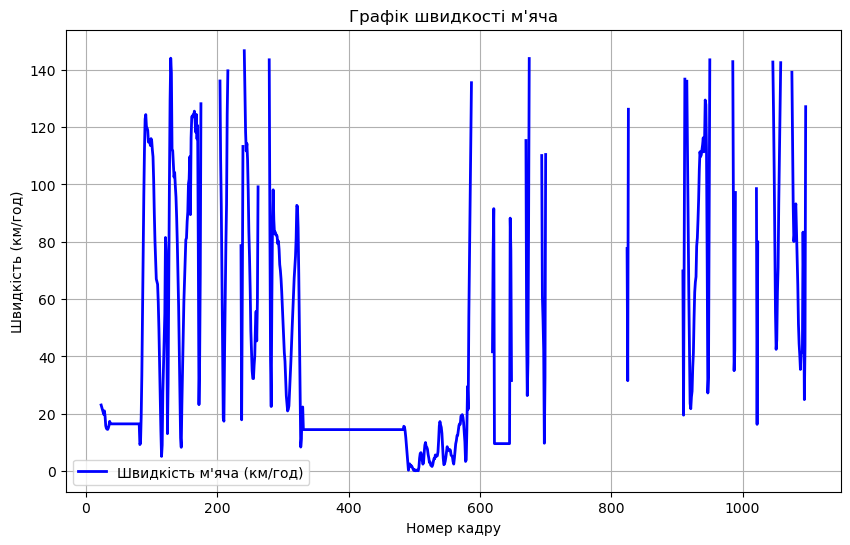

In [26]:
df = process_ball_trajectory(raw_detections, fps=50)

In [9]:
df

,frame,x_meters,y_meters
0,22,1.141766,9.461248
1,23,1.122942,9.384870
2,24,1.111833,9.326942
3,25,1.083458,9.171156
4,26,1.053186,9.032770
...,...,...,...
678,1108,19.624636,-67.078552
679,1109,21.804277,-81.530975
680,1110,24.799860,-101.045509
681,1111,28.276459,-124.554825
